# Cross-case 2D--3D submesoscale-activity agreement


In [81]:
# ============================================================
# 1. IMPORTS AND PROJECT PATHS
# ============================================================

from pathlib import Path
import sys
import json
import importlib
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"
RESULTS_ROOT = FLOW_DIR / "results"

for path in [PROJECT_DIR, FLOW_SCRIPTS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import theme.plot_theme as ptheme
import shcherbina_utils as shu

importlib.reload(ptheme)
ptheme.apply_theme()

importlib.reload(shu)
shu.apply_plot_style()

def apply_cross_case_style():
    shu.apply_plot_style()
    plt.rcParams.update({
        "font.size": max(getattr(ptheme, "FONT_SIZE", 14), 19),
        "axes.titlesize": max(getattr(ptheme, "TITLE_SIZE", 20), 24),
        "axes.labelsize": max(getattr(ptheme, "LABEL_SIZE", 18), 22),
        "xtick.labelsize": max(getattr(ptheme, "TICK_SIZE", 16), 18),
        "ytick.labelsize": max(getattr(ptheme, "TICK_SIZE", 16), 18),
        "legend.fontsize": max(getattr(ptheme, "LEGEND_SIZE", 15), 17),
        "figure.titlesize": max(getattr(ptheme, "SUPTITLE_SIZE", 24), 27),
    })

apply_cross_case_style()

print(f"Notebook dir : {NB_DIR}")
print(f"Results root : {RESULTS_ROOT}")


Notebook dir : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\notebooks
Results root : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results


C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\

In [ ]:
# ============================================================
# 2. USER SETTINGS
# ============================================================

CASE_NAMES = [
    "run_aug1",
    "run_aug1_f1",
    "run_aug1_f2",
    "run_aug2",
    "run_aug3",
    "run_dec1",
    "run_dec2",
    "run_feb1",
    "run_jan1",
    "run_jul1",
    "run_jun1",
    "run_mar1",
    "run_may1",
    "run_nov1",
    "run_oct1",
    "run_sep1",
]

# Change only this setting to colour by another characteristic.
COLOR_VARIABLE = "epsilon_proxy_m2_s3"

# "auto" uses logarithmic colour normalization for epsilon, EKE and Ri.
COLOR_SCALE = "auto"  # "auto", "linear", or "log"
COLOR_MAP = "viridis"

COLOR_LABELS = {
    "glorys_mld_median_m": "GLORYS median MLD [m]",
    "mld_median_m": "MITgcm median MLD [m]",
    "epsilon_proxy_m2_s3": r"$\epsilon$ proxy [m$^2$ s$^{-3}$]",
    "eke_mean_m2_s2": r"Mean EKE [m$^2$ s$^{-2}$]",
    "Ri_b_median": r"Median bulk $Ri_b$",
    "ow_ett.epsilon_eddy_median_m2_s3":
        r"Median eddy $\epsilon$ [m$^2$ s$^{-3}$]",
}

ACTIVITY_LIMITS = (1.0e-5, 5.0e-1)
MARKERS = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]

ANNOTATE_CASE_NAMES = False
CONNECT_CASE_SNAPSHOTS = False
SKIP_MISSING_CASES = True

SAVE_FIGURE = True
SAVE_SUMMARY_CSV = False

OUTPUT_DIR = RESULTS_ROOT
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Colour variable : {COLOR_VARIABLE}")
print(f"Output directory: {OUTPUT_DIR}")


Colour variable : eke_mean_m2_s2
Output directory: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results


In [ ]:
# ============================================================
# 3. INPUT HELPERS
# ============================================================

def get_nested_value(mapping, key):
    value = mapping
    for part in key.split("."):
        if not isinstance(value, dict) or part not in value:
            raise KeyError(key)
        value = value[part]
    return value

def find_domain_characterization_file(case_dir, case_name):
    preferred = case_dir / f"{case_name}_domain_characterization.json"
    if preferred.exists():
        return preferred

    candidates = sorted(case_dir.glob("*domain_characterization*.json"))
    if len(candidates) == 1:
        return candidates[0]
    if not candidates:
        raise FileNotFoundError(
            f"No domain-characterization JSON found in {case_dir}"
        )
    raise RuntimeError(
        f"Multiple domain-characterization files found in {case_dir}: "
        f"{[path.name for path in candidates]}"
    )

def find_activity_file(case_dir):
    candidates = [
        case_dir / "metrics" / "submesoscale_activity_selected_snapshots.nc",
        case_dir / "submesoscale_activity_selected_snapshots.nc",
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"No selected-snapshot activity NetCDF found in {case_dir}"
    )

def read_case_records(case_name, color_variable):
    case_dir = RESULTS_ROOT / case_name
    activity_file = find_activity_file(case_dir)
    characterization_file = find_domain_characterization_file(
        case_dir, case_name
    )

    with characterization_file.open("r", encoding="utf-8") as handle:
        characterization = json.load(handle)

    color_value = float(
        get_nested_value(characterization, color_variable)
    )
    run_title = characterization.get("run_title_info", case_name)

    with xr.open_dataset(activity_file) as ds:
        for variable in ["active_fraction_3d", "active_fraction_2d"]:
            if variable not in ds:
                raise KeyError(f"{activity_file} is missing {variable}")

        times = (
            ds["time_days_3d"].values
            if "time_days_3d" in ds
            else np.arange(ds.sizes["snapshot"], dtype=float)
        )
        obs_indices = (
            ds["obs_index"].values
            if "obs_index" in ds
            else np.arange(ds.sizes["snapshot"], dtype=int)
        )
        active_3d = ds["active_fraction_3d"].values
        active_2d = ds["active_fraction_2d"].values
        # case_2d = ds.attrs.get("case_2d", f"{case_name}_2D")
        case_1000m = ds.attrs.get("case_1000m", f"{case_name}_1000m")
        case_2d = case_1000m


    return [
        {
            "case_3d": case_name,
            "case_2d": case_2d,
            "run_title_info": run_title,
            "snapshot": int(snapshot),
            "obs_index": int(obs_index),
            "time_days": float(time_day),
            "active_fraction_3d": float(value_3d),
            "active_fraction_2d": float(value_2d),
            "color_value": color_value,
        }
        for snapshot, (time_day, obs_index, value_3d, value_2d)
        in enumerate(zip(times, obs_indices, active_3d, active_2d))
    ]


In [84]:
# ============================================================
# 4. LOAD ALL CASES
# ============================================================

records = []
skipped_cases = []

for case_name in CASE_NAMES:
    try:
        case_records = read_case_records(case_name, COLOR_VARIABLE)
        records.extend(case_records)
        print(f"Loaded {case_name}: {len(case_records)} snapshots")
    except Exception as exc:
        message = f"{case_name}: {type(exc).__name__}: {exc}"
        if SKIP_MISSING_CASES:
            skipped_cases.append(message)
            warnings.warn(message)
        else:
            raise

comparison_df = (
    pd.DataFrame(records)
    .sort_values(["case_3d", "time_days"])
    .reset_index(drop=True)
)

if comparison_df.empty:
    raise RuntimeError("No valid case data were loaded.")

display(comparison_df[[
    "case_3d",
    "time_days",
    "active_fraction_2d",
    "active_fraction_3d",
    "color_value",
]])

if skipped_cases:
    print("\nSkipped cases:")
    for message in skipped_cases:
        print(f"  - {message}")

if SAVE_SUMMARY_CSV:
    csv_path = (
        OUTPUT_DIR
        / f"submesoscale_activity_{COLOR_VARIABLE.replace('.', '_')}.csv"
    )
    comparison_df.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")


Loaded run_aug1: 4 snapshots
Loaded run_aug1_f1: 4 snapshots
Loaded run_aug1_f2: 4 snapshots
Loaded run_aug2: 4 snapshots
Loaded run_aug3: 4 snapshots
Loaded run_dec1: 4 snapshots
Loaded run_dec2: 4 snapshots
Loaded run_feb1: 4 snapshots
Loaded run_jan1: 4 snapshots
Loaded run_jul1: 4 snapshots
Loaded run_jun1: 4 snapshots
Loaded run_mar1: 4 snapshots
Loaded run_may1: 4 snapshots
Loaded run_nov1: 4 snapshots
Loaded run_oct1: 4 snapshots
Loaded run_sep1: 4 snapshots


,case_3d,time_days,active_fraction_2d,active_fraction_3d,color_value
0,run_aug1,0.0,0.012894,0.012600,0.010474
1,run_aug1,3.0,0.007889,0.012199,0.010474
2,run_aug1,7.0,0.005337,0.010735,0.010474
3,run_aug1,13.0,0.003620,0.006004,0.010474
4,run_aug1_f1,0.0,0.014370,0.013107,0.011094
...,...,...,...,...,...
59,run_oct1,13.0,0.000000,0.000000,0.006801
60,run_sep1,0.0,0.008572,0.006218,0.015598
61,run_sep1,3.0,0.004108,0.005863,0.015598
62,run_sep1,7.0,0.002335,0.004719,0.015598


C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\submesoscale_activity_2D_vs_3D_eke_mean_m2_s2.png


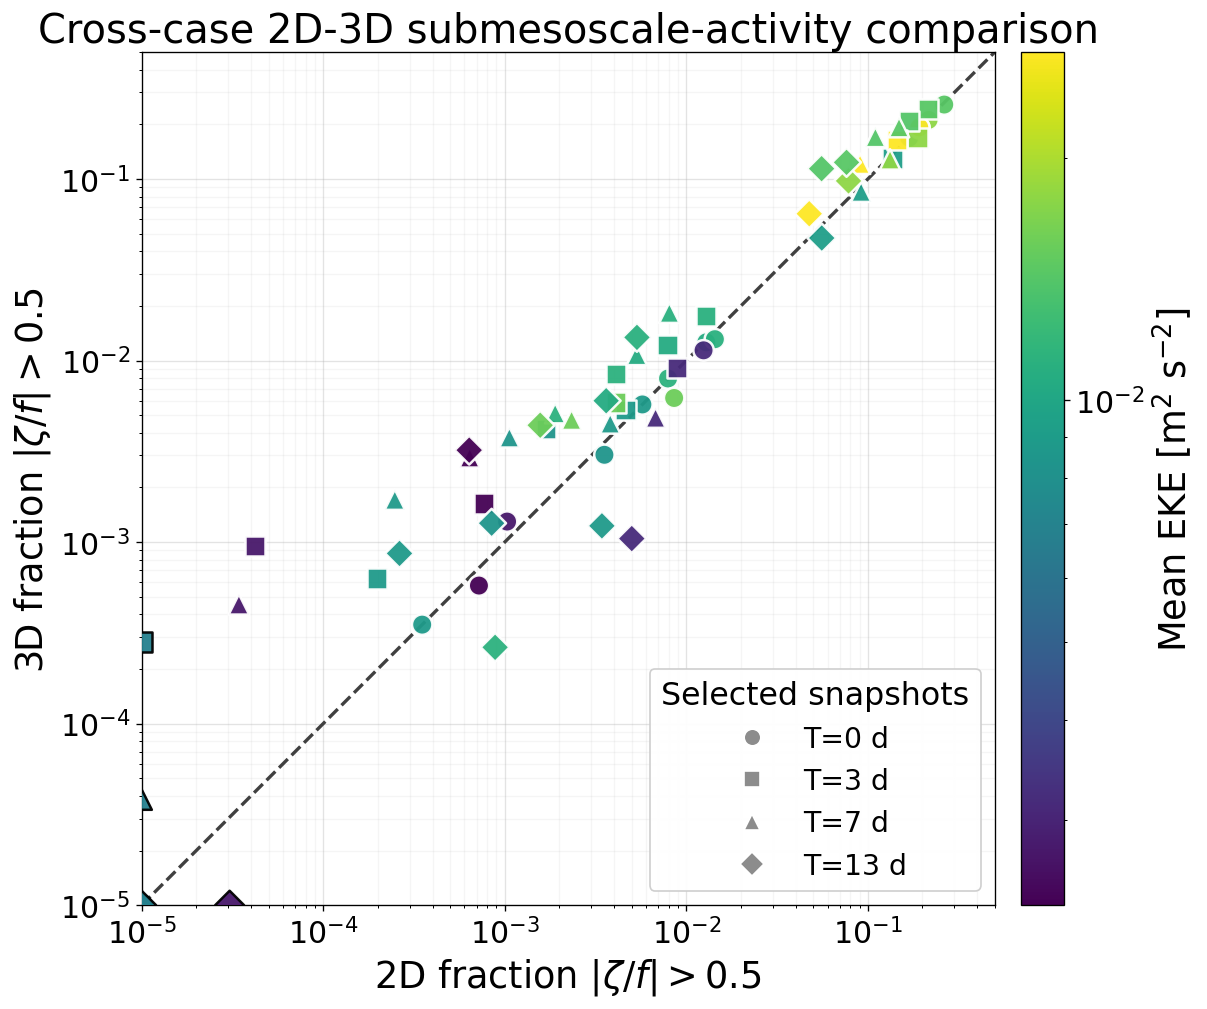

In [85]:
# ============================================================
# 5. CROSS-CASE LOG--LOG AGREEMENT PLOT
# ============================================================

def infer_color_scale(variable, requested_scale):
    if requested_scale != "auto":
        return requested_scale

    name = variable.lower()
    return (
        "log"
        if any(token in name for token in ["epsilon", "eke", "ri_"])
        else "linear"
    )

def plot_cross_case_activity(data):
    apply_cross_case_style()
    data = data.copy()

    finite = np.isfinite(
        data[[
            "active_fraction_2d",
            "active_fraction_3d",
            "color_value",
        ]]
    ).all(axis=1)
    data = data.loc[finite].copy()

    lower, upper = ACTIVITY_LIMITS
    data["x_plot"] = data["active_fraction_2d"].clip(lower, upper)
    data["y_plot"] = data["active_fraction_3d"].clip(lower, upper)
    data["clipped"] = (
        (data["active_fraction_2d"] < lower)
        | (data["active_fraction_3d"] < lower)
        | (data["active_fraction_2d"] > upper)
        | (data["active_fraction_3d"] > upper)
    )

    color_scale = infer_color_scale(COLOR_VARIABLE, COLOR_SCALE)
    color_values = data["color_value"].to_numpy(dtype=float)

    if color_scale == "log":
        if np.any(color_values <= 0.0):
            raise ValueError(
                f"{COLOR_VARIABLE} contains non-positive values."
            )
        norm = LogNorm(color_values.min(), color_values.max())
    elif color_scale == "linear":
        norm = Normalize(color_values.min(), color_values.max())
    else:
        raise ValueError("COLOR_SCALE must be auto, linear, or log.")

    cmap = plt.get_cmap(COLOR_MAP)
    days = sorted(data["time_days"].unique())

    if len(days) > len(MARKERS):
        raise ValueError("Add more marker definitions.")

    marker_by_day = {
        day: MARKERS[index]
        for index, day in enumerate(days)
    }

    fig, ax = plt.subplots(figsize=(10.8, 9.2), facecolor="white")
    ax.set_facecolor("white")

    if CONNECT_CASE_SNAPSHOTS:
        for _, case_data in data.groupby("case_3d"):
            case_data = case_data.sort_values("time_days")
            ax.plot(
                case_data["x_plot"],
                case_data["y_plot"],
                color="0.70",
                lw=1.0,
                alpha=0.45,
                zorder=1,
            )

    for day in days:
        subset = data[data["time_days"] == day]
        edgecolors = [
            "black" if clipped else "white"
            for clipped in subset["clipped"] 
        ]

        ax.scatter(
            subset["x_plot"],
            subset["y_plot"],
            c=subset["color_value"],
            cmap=cmap,
            norm=norm,
            marker=marker_by_day[day],
            s=150,
            edgecolors=edgecolors,
            linewidths=1.5,
            alpha=0.95,
            zorder=3,
        )

    agreement = np.geomspace(lower, upper, 300)
    reference_color = shu.get_color("reference")
    ax.plot(
        agreement,
        agreement,
        "--",
        color=reference_color,
        lw=2.0,
        zorder=2,
    )

    if ANNOTATE_CASE_NAMES:
        for _, row in data.iterrows():
            ax.annotate(
                row["case_3d"],
                (row["x_plot"], row["y_plot"]),
                xytext=(5, 4),
                textcoords="offset points",
                fontsize=10,
            )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(r"2D fraction $|\zeta/f|>0.5$")
    ax.set_ylabel(r"3D fraction $|\zeta/f|>0.5$")
    ax.set_title("Cross-case 2D-3D submesoscale-activity comparison")

    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.12)

    legend_handles = [
        Line2D(
            [0], [0],
            marker=marker_by_day[day],
            linestyle="none",
            markerfacecolor="0.55",
            markeredgecolor="white",
            markersize=10,
            label=f"T={day:g} d",
        )
        for day in days
    ]

    ax.legend(
        handles=legend_handles,
        loc="lower right",
        frameon=True,
        framealpha=0.95,
        title="Selected snapshots",
    )

    mappable = ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array([])
    colorbar = fig.colorbar(
        mappable,
        ax=ax,
        pad=0.025,
        fraction=0.05,
    )
    colorbar.set_label(
        COLOR_LABELS.get(COLOR_VARIABLE, COLOR_VARIABLE)
    )

    fig.tight_layout(rect=(0.0, 0.045, 1.0, 1.0))

    if SAVE_FIGURE:
        output_file = (
            OUTPUT_DIR
            / (
                "submesoscale_activity_2D_vs_3D_"
                f"{COLOR_VARIABLE.replace('.', '_')}.png"
            )
        )
        fig.savefig(
            output_file,
            dpi=getattr(ptheme, "SAVE_DPI", 300),
            bbox_inches="tight",
            facecolor="white",
            transparent=False,
        )
        print(f"Saved: {output_file}")

    plt.show()
    return fig, ax

fig, ax = plot_cross_case_activity(comparison_df)
